  # Working with filing data from the SEC's EDGAR service

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
%matplotlib inline

from pathlib import Path
from datetime import date
import json
from io import BytesIO
from zipfile import ZipFile, BadZipFile
from tqdm import tqdm
import requests

import pandas_datareader.data as web
import yfinance as yf
import pandas as pd

from pprint import pprint

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [ ]:
sns.set_style('whitegrid')

In [ ]:
# --- Parameters ---
DATA_DIR = 'data'
START_DATE = '2014'
END_DATE = '2025-12-31'
TARGET_COMPANY = 'APPLE INC'
TARGET_TICKER = 'AAPL' # for yfinance
STOCK_SPLIT = 7
SPLIT_DATE = pd.to_datetime('20140604')
USER_AGENT = 'MachineLearningForTrading_Student admin@ml4t.com'
# ------------------

In [ ]:
# store data in this directory since we won't use it in other chapters
data_path = Path(DATA_DIR) # perhaps set to external harddrive to accomodate large amount of data
if not data_path.exists():
    data_path.mkdir(parents=True)

  ## Download FS & Notes Data

  The following code downloads and extracts all historical filings contained in the [Financial Statement and Notes](https://www.sec.gov/dera/data/financial-statement-and-notes-data-set.html) (FSN) datasets from Q1/2014 through Q3/2020.

  > The SEC has moved to a monthly cadence after Q3/2020; feel free to extend the code by creating the correpsonding file names (see linked website) and download those as well.

  **Downloads over 40GB of data!**

In [ ]:
SEC_URL = 'https://www.sec.gov/'
FSN_PATH = 'files/dera/data/financial-statement-notes-data-sets/'

In [ ]:
filing_periods = [(d.year, d.quarter) for d in pd.date_range(START_DATE, END_DATE, freq='Q')]
filing_periods

[(2014, 1),
 (2014, 2),
 (2014, 3),
 (2014, 4),
 (2015, 1),
 (2015, 2),
 (2015, 3),
 (2015, 4),
 (2016, 1),
 (2016, 2),
 (2016, 3),
 (2016, 4),
 (2017, 1),
 (2017, 2),
 (2017, 3),
 (2017, 4),
 (2018, 1),
 (2018, 2),
 (2018, 3),
 (2018, 4),
 (2019, 1),
 (2019, 2),
 (2019, 3),
 (2019, 4),
 (2020, 1),
 (2020, 2),
 (2020, 3),
 (2020, 4),
 (2021, 1),
 (2021, 2),
 (2021, 3),
 (2021, 4),
 (2022, 1),
 (2022, 2),
 (2022, 3),
 (2022, 4),
 (2023, 1),
 (2023, 2),
 (2023, 3),
 (2023, 4),
 (2024, 1),
 (2024, 2),
 (2024, 3),
 (2024, 4),
 (2025, 1),
 (2025, 2),
 (2025, 3),
 (2025, 4)]

In [ ]:
for yr, qtr in tqdm(filing_periods):
    # set (and create) directory
    path = data_path / f'{yr}_{qtr}' / 'source'
    if not path.exists():
        path.mkdir(parents=True)
    
    # define url and get file
    filing = f'{yr}q{qtr}_notes.zip'
    url = SEC_URL + FSN_PATH + filing
    headers = {'User-Agent': USER_AGENT}
    
    if len(list(path.glob('*.*'))) > 0:
        print(f'Already downloaded and extracted {yr} Q{qtr}')
        continue
        
    response = requests.get(url, headers=headers).content
    
    # decompress and save
    try:
        with ZipFile(BytesIO(response)) as zip_file:
            for file in zip_file.namelist():
                local_file = path / file
                if local_file.exists():
                    continue
                with local_file.open('wb') as output:
                    for line in zip_file.open(file).readlines():
                        output.write(line)
    except BadZipFile:
        print(f'\nBad zip file: {yr} {qtr}\n')
        continue

  0%|          | 0/48 [00:00<?, ?it/s]

Already downloaded and extracted 2014 Q1
Already downloaded and extracted 2014 Q2
Already downloaded and extracted 2014 Q3
Already downloaded and extracted 2014 Q4
Already downloaded and extracted 2015 Q1
Already downloaded and extracted 2015 Q2
Already downloaded and extracted 2015 Q3
Already downloaded and extracted 2015 Q4
Already downloaded and extracted 2016 Q1
Already downloaded and extracted 2016 Q2
Already downloaded and extracted 2016 Q3
Already downloaded and extracted 2016 Q4
Already downloaded and extracted 2017 Q1
Already downloaded and extracted 2017 Q2
Already downloaded and extracted 2017 Q3
Already downloaded and extracted 2017 Q4
Already downloaded and extracted 2018 Q1
Already downloaded and extracted 2018 Q2
Already downloaded and extracted 2018 Q3
Already downloaded and extracted 2018 Q4
Already downloaded and extracted 2019 Q1
Already downloaded and extracted 2019 Q2
Already downloaded and extracted 2019 Q3
Already downloaded and extracted 2019 Q4
Already download

 94%|█████████▍| 45/48 [00:00<00:00, 109.12it/s]


Bad zip file: 2025 1


Bad zip file: 2025 2


Bad zip file: 2025 3



100%|██████████| 48/48 [00:01<00:00, 24.65it/s] 


Bad zip file: 2025 4



  ## Save to parquet

  The data is fairly large and to enable faster access than the original text files permit, it is better to convert the text files to binary, columnar parquet format (see Section 'Efficient data storage with pandas' in chapter 2 for a performance comparison of various data-storage options compatible with pandas DataFrames):

  > Some fo the `txt.tsv` source files contain a small number of faulty lines; the code below drops those lines but indicates the line numbers where you can find the errors if you would like to investigate further.

In [ ]:
for f in tqdm(sorted(list(data_path.glob('**/*.tsv')))):
    # set (and create) directory
    parquet_path = f.parent.parent / 'parquet'
    if not parquet_path.exists():
        parquet_path.mkdir(parents=True)    

    # write content to .parquet
    file_name = f.stem  + '.parquet'
    if not (parquet_path / file_name).exists():
        try:
            df = pd.read_csv(f, sep='\t', encoding='latin1', low_memory=False, on_bad_lines='skip')
            df.to_parquet(parquet_path / file_name)
        except Exception as e:
            print(e, ' | ', f)
        # optional: uncomment to delete original .tsv
#         else:
            # f.unlink

100%|██████████| 352/352 [00:00<00:00, 66666.44it/s]


  ## Metadata json

In [ ]:
sample_yr, sample_qtr = filing_periods[0]
sample_dir = f'{sample_yr}_{sample_qtr}'
file = data_path / sample_dir / 'source' / f'{sample_yr}q{sample_qtr}_notes-metadata.json'
with file.open() as f:
    data = json.load(f)

pprint(data)

{'@context': 'http://www.w3.org/ns/csvw',
 'dialect': {'delimiter': '\t', 'header': True, 'headerRowCount': 1},
 'tables': [{'tableSchema': {'aboutUrl': 'readme.htm',
                             'columns': [{'datatype': {'base': 'string',
                                                       'maxLength': 20,
                                                       'minLength': 20},
                                          'dc:description': 'Accession Number. '
                                                            'The 20-character '
                                                            'string formed '
                                                            'from the 18-digit '
                                                            'number assigned '
                                                            'by the Commission '
                                                            'to each EDGAR '
                                                           

  ## Data Organization

  For each quarter, the FSN data is organized into eight file sets that contain information about submissions, numbers, taxonomy tags, presentation, and more. Each dataset consists of rows and fields and is provided as a tab-delimited text file:

  | File | Dataset      | Description                                                 |
  |------|--------------|-------------------------------------------------------------|
  | SUB  | Submission   | Identifies each XBRL submission by company, form, date, etc |
  | TAG  | Tag          | Defines and explains each taxonomy tag                      |
  | DIM  | Dimension    | Adds detail to numeric and plain text data                  |
  | NUM  | Numeric      | One row for each distinct data point in filing              |
  | TXT  | Plain Text   | Contains all non-numeric XBRL fields                        |
  | REN  | Rendering    | Information for rendering on SEC website                    |
  | PRE  | Presentation | Detail on tag and number presentation in primary statements |
  | CAL  | Calculation  | Shows arithmetic relationships among tags                   |

  ## Submission Data

  The latest submission file contains around 6,500 entries.

In [ ]:
sub = pd.read_parquet(data_path / sample_dir / 'parquet' / 'sub.parquet')
sub.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7161 entries, 0 to 7160
Data columns (total 40 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   adsh         7161 non-null   object 
 1   cik          7161 non-null   int64  
 2   name         7161 non-null   object 
 3   sic          7161 non-null   int64  
 4   countryba    7131 non-null   object 
 5   stprba       6619 non-null   object 
 6   cityba       7134 non-null   object 
 7   zipba        7128 non-null   object 
 8   bas1         7133 non-null   object 
 9   bas2         3086 non-null   object 
 10  baph         7114 non-null   object 
 11  countryma    7038 non-null   object 
 12  stprma       6554 non-null   object 
 13  cityma       7039 non-null   object 
 14  zipma        7034 non-null   object 
 15  mas1         7038 non-null   object 
 16  mas2         3018 non-null   object 
 17  countryinc   6492 non-null   object 
 18  stprinc      6313 non-null   object 
 19  ein   

  ### Get AAPL submission

  The submission dataset contains the unique identifiers required to retrieve the filings: the Central Index Key (CIK) and the Accession Number (adsh). The following shows some of the information about Apple's 2018Q1 10-Q filing:

In [ ]:
apple = sub[sub.name == TARGET_COMPANY].T.dropna().squeeze()
key_cols = ['name', 'adsh', 'cik', 'name', 'sic', 'countryba', 'stprba',
            'cityba', 'zipba', 'bas1', 'form', 'period', 'fy', 'fp', 'filed']
apple.loc[key_cols]

name                    APPLE INC
adsh         0001193125-14-024487
cik                        320193
name                    APPLE INC
sic                          3571
countryba                      US
stprba                         CA
cityba                  CUPERTINO
zipba                       95014
bas1            ONE INFINITE LOOP
form                         10-Q
period                   20131231
fy                         2014.0
fp                             Q1
filed                    20140128
Name: 661, dtype: object

  ## Build AAPL fundamentals dataset

  Using the central index key, we can identify all historical quarterly filings available for Apple, and combine this information to obtain 26 Forms 10-Q and nine annual Forms 10-K.

  ### Get filings

In [ ]:
aapl_subs = pd.DataFrame()
for sub in data_path.glob('**/sub.parquet'):
    sub = pd.read_parquet(sub)
    aapl_sub = sub[(sub.cik.astype(int) == apple.cik) & (sub.form.isin(['10-Q', '10-K']))]
    aapl_subs = pd.concat([aapl_subs, aapl_sub])

  We find 15 quarterly 10-Q and 4 annual 10-K reports:

In [ ]:
aapl_subs.form.value_counts()

form
10-Q    33
10-K    11
Name: count, dtype: int64

  ### Get numerical filing data

  With the Accession Number for each filing, we can now rely on the taxonomies to select the appropriate XBRL tags (listed in the TAG file) from the NUM and TXT files to obtain the numerical or textual/footnote data points of interest.

  First, let's extract all numerical data available from the 19 Apple filings:

In [ ]:
aapl_nums = pd.DataFrame()
for num in data_path.glob('**/num.parquet'):
    num = pd.read_parquet(num).drop('dimh', axis=1)
    aapl_num = num[num.adsh.isin(aapl_subs.adsh)]
    print(len(aapl_num))
    aapl_nums = pd.concat([aapl_nums, aapl_num])
aapl_nums.ddate = pd.to_datetime(aapl_nums.ddate, format='%Y%m%d')   
aapl_nums.to_parquet(data_path / 'aapl_nums.parquet')

751
951
1039
1176
1001
1364
1035
526
1020
745
784
752
707
805
793
919
1271
1034
955
576
954
942
738
755
1345
961
1028
1223
680
1017
581
683
963
905
682
1224
937
1277
923
952
736
995
738
714


  In total, the nine years of filing history provide us with over 18,000 numerical values for AAPL.

In [ ]:
aapl_nums.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40157 entries, 4298 to 8346472
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   adsh      40157 non-null  object        
 1   tag       40157 non-null  object        
 2   version   40157 non-null  object        
 3   ddate     40157 non-null  datetime64[ns]
 4   qtrs      40157 non-null  int64         
 5   uom       40157 non-null  object        
 6   iprx      40157 non-null  int64         
 7   value     40059 non-null  float64       
 8   footnote  68 non-null     object        
 9   footlen   40157 non-null  int64         
 10  dimn      40157 non-null  int64         
 11  coreg     0 non-null      object        
 12  durp      40157 non-null  float64       
 13  datp      40157 non-null  float64       
 14  dcml      40157 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(5), object(6)
memory usage: 4.9+ MB


  ## Create P/E Ratio from EPS and stock price data

  We can select a useful field, such as Earnings per Diluted Share (EPS), that we can combine with market data to calculate the popular Price/Earnings (P/E) valuation ratio.

In [ ]:
SPLIT_DATE

Timestamp('2014-06-04 00:00:00')

  We do need to take into account, however, that Apple split its stock 7:1 on June 4, 2014, and Adjusted Earnings per Share before the split to make earnings comparable, as illustrated in the following code block:

In [ ]:
# Filter by tag; keep only values measuring 1 quarter
eps = aapl_nums[(aapl_nums.tag == 'EarningsPerShareDiluted')
                & (aapl_nums.qtrs == 1)].drop('tag', axis=1)

# Keep only most recent data point from each filing
eps = eps.groupby('adsh').apply(lambda x: x.nlargest(n=1, columns=['ddate']))

# Adjust earnings prior to stock split downward
eps.loc[eps.ddate < SPLIT_DATE,'value'] = eps.loc[eps.ddate < SPLIT_DATE, 'value'].div(STOCK_SPLIT)
eps = eps[['ddate', 'value']].set_index('ddate').squeeze().sort_index()
eps = eps.rolling(4,min_periods=4).sum().dropna()

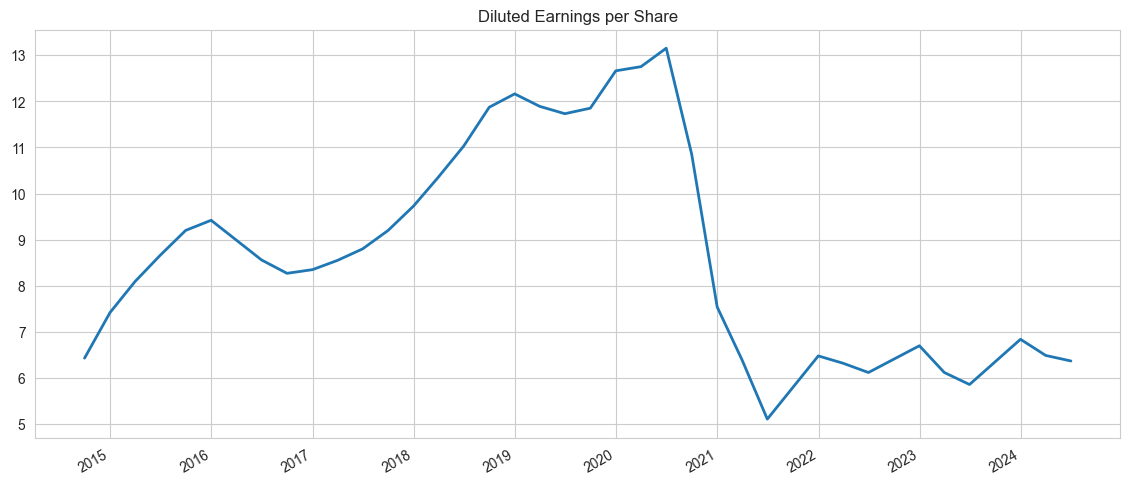

In [ ]:
eps.plot(lw=2, figsize=(14, 6), title='Diluted Earnings per Share')
plt.xlabel('')
plt.savefig('diluted eps', dpi=300);

In [ ]:
aapl_stock = yf.Ticker(TARGET_TICKER).history(start=eps.index.min())
aapl_stock.index = aapl_stock.index.tz_localize(None)
aapl_stock = (aapl_stock
              .rename(columns={'Close': 'AdjClose'})
              .resample('D')
              .last()
             .loc[START_DATE:eps.index.max()])
aapl_stock.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3562 entries, 2014-09-30 to 2024-06-30
Freq: D
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          2453 non-null   float64
 1   High          2453 non-null   float64
 2   Low           2453 non-null   float64
 3   AdjClose      2453 non-null   float64
 4   Volume        2453 non-null   float64
 5   Dividends     2453 non-null   float64
 6   Stock Splits  2453 non-null   float64
dtypes: float64(7)
memory usage: 222.6 KB


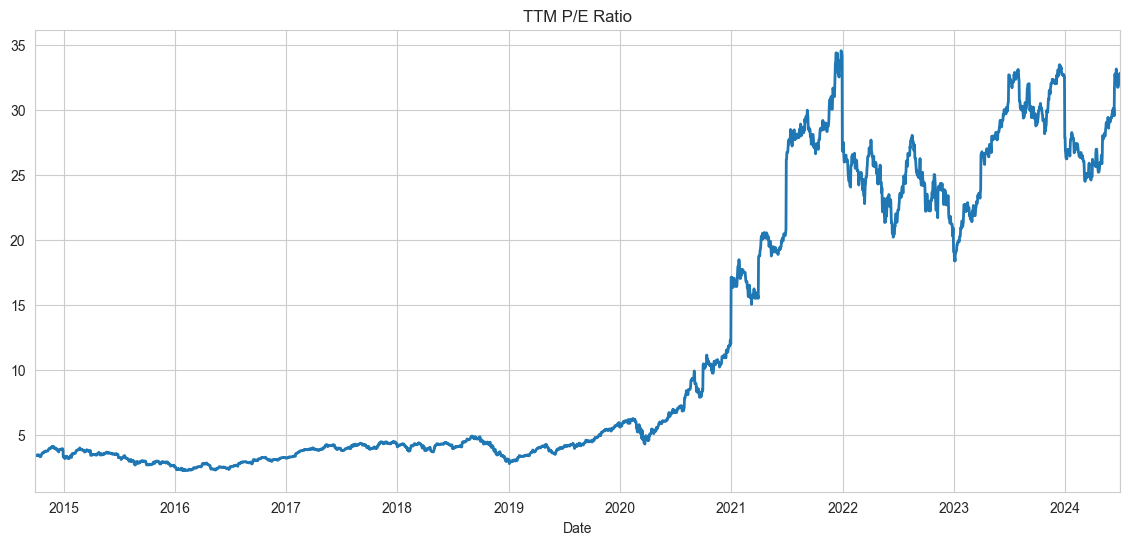

In [ ]:
pe = aapl_stock.AdjClose.to_frame('price').join(eps.to_frame('eps'))
pe = pe.fillna(method='ffill').dropna()
pe['P/E Ratio'] = pe.price.div(pe.eps)
pe['P/E Ratio'].plot(lw=2, figsize=(14, 6), title='TTM P/E Ratio');

In [ ]:
pe.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3562 entries, 2014-09-30 to 2024-06-30
Freq: D
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   price      3562 non-null   float64
 1   eps        3562 non-null   float64
 2   P/E Ratio  3562 non-null   float64
dtypes: float64(3)
memory usage: 111.3 KB


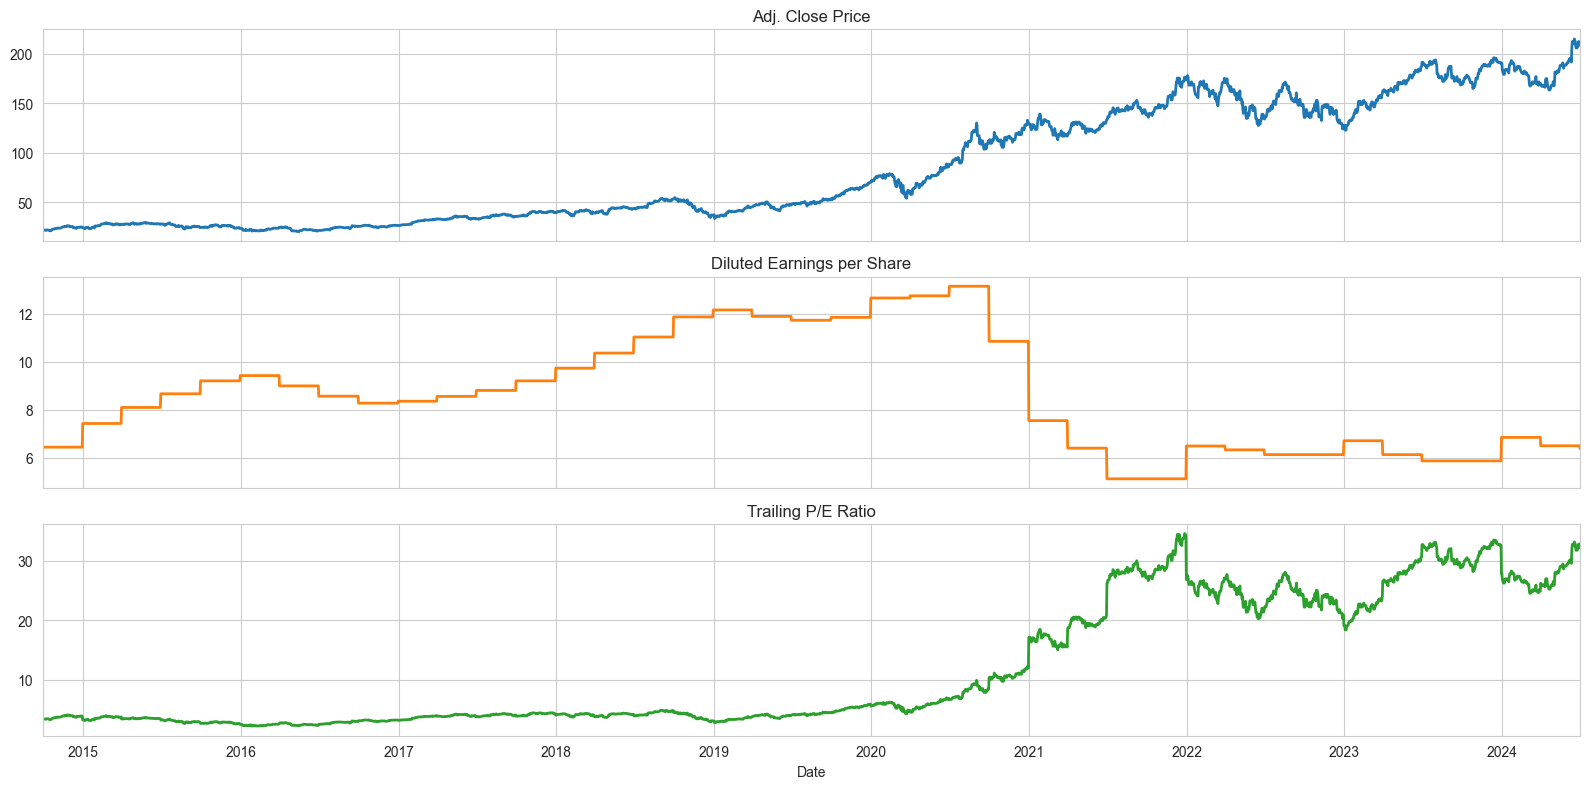

In [ ]:
axes = pe.plot(subplots=True, figsize=(16,8), legend=False, lw=2)
axes[0].set_title('Adj. Close Price')
axes[1].set_title('Diluted Earnings per Share')
axes[2].set_title('Trailing P/E Ratio')
plt.tight_layout();

  ## Explore Additional Fields

  The field `tag` references values defined in the taxonomy:

In [ ]:
aapl_nums.tag.value_counts()

tag
CashAndCashEquivalentsAtCarryingValue                                                                          1323
RevenueFromContractWithCustomerExcludingAssessedTax                                                            1176
OperatingIncomeLoss                                                                                            1090
StockholdersEquity                                                                                             1005
DebtInstrumentInterestRateEffectivePercentage                                                                   861
                                                                                                               ... 
ShareBasedCompensationArrangementsByShareBasedPaymentAwardOptionsGrantsInPeriodWeightedAverageExercisePrice       1
ResultOfLegalProceedingsAdditionalAmountAwarded                                                                   1
ResultOfLegalProceedingsAwardUpHeld                                 

  We can select values of interest and track their value or use them as inputs to compute fundamental metrics like the Dividend/Share ratio.

  ### Dividends per Share

In [ ]:
fields = ['EarningsPerShareDiluted',
          'PaymentsOfDividendsCommonStock',
          'WeightedAverageNumberOfDilutedSharesOutstanding',
          'OperatingIncomeLoss',
          'NetIncomeLoss',
          'GrossProfit']

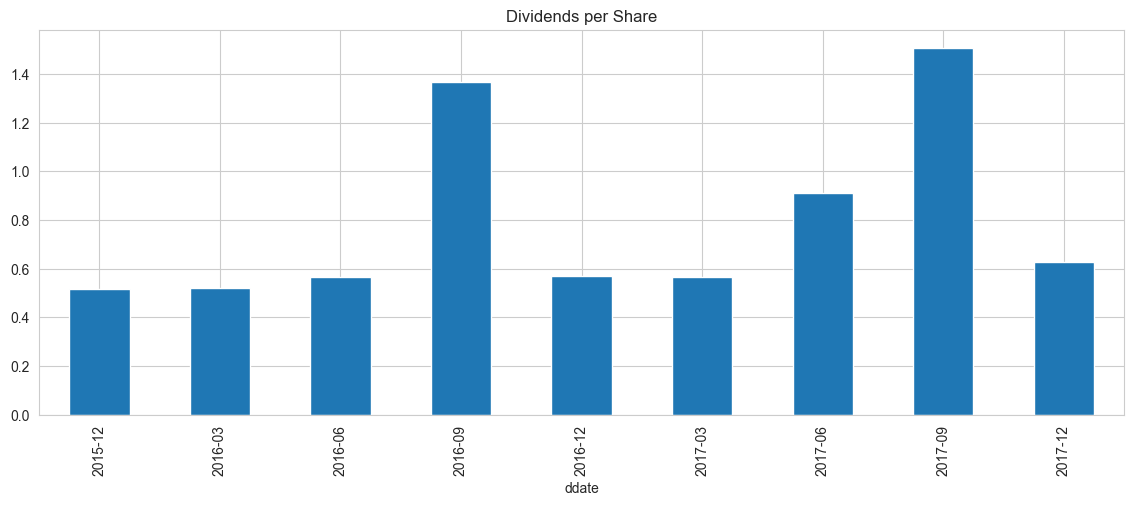

In [ ]:
dividends = (aapl_nums
             .loc[aapl_nums.tag == 'PaymentsOfDividendsCommonStock', ['ddate', 'value']]
             .groupby('ddate')
             .mean())
shares = (aapl_nums
          .loc[aapl_nums.tag == 'WeightedAverageNumberOfDilutedSharesOutstanding', ['ddate', 'value']]
          .drop_duplicates()
          .groupby('ddate')
          .mean())
df = dividends.div(shares).dropna()
ax = df.plot.bar(figsize=(14, 5), title='Dividends per Share', legend=False)
ax.xaxis.set_major_formatter(mticker.FixedFormatter(df.index.strftime('%Y-%m')))

  ## Bonus: Textual Information

In [ ]:
txt = pd.read_parquet(data_path / sample_dir / 'parquet' /  'txt.parquet')

  AAPL's adsh is not avaialble in the txt file but you can obtain notes from the financial statements here:

In [ ]:
txt.head()

,adsh,tag,version,ddate,qtrs,iprx,lang,dcml,durp,datp,dimh,dimn,coreg,escaped,srclen,txtlen,footnote,footlen,context,value
0,0000721748-14-000003,EntityRegistrantName,dei/2013,20130630,4,0,en-US,32767,0.010959,0.0,0x00000000,0,None,0,19,19,None,0,From2012-07-01to2013-06-30,M LINE HOLDINGS INC
1,0000721748-14-000003,EntityCentralIndexKey,dei/2013,20130630,4,0,en-US,32767,0.010959,0.0,0x00000000,0,None,0,10,10,None,0,From2012-07-01to2013-06-30,0001072248
2,0000721748-14-000003,DocumentType,dei/2013,20130630,4,0,en-US,32767,0.010959,0.0,0x00000000,0,None,0,4,4,None,0,From2012-07-01to2013-06-30,10-K
3,0000721748-14-000003,DocumentPeriodEndDate,dei/2013,20130630,4,0,en-US,32767,0.010959,0.0,0x00000000,0,None,0,10,10,None,0,From2012-07-01to2013-06-30,2013-06-30
4,0000721748-14-000003,AmendmentFlag,dei/2013,20130630,4,0,en-US,32767,0.010959,0.0,0x00000000,0,None,0,5,5,None,0,From2012-07-01to2013-06-30,false
